# HMM-Diffusion

Regime-conditional synthetic financial time series. Volatility regimes are detected on S&P 500 total return (A001) log returns, one diffusion specialist is trained per regime, and an HMM estimates the regime path used to stitch specialist output into a single series.

Vol_Regime is run on A001 over **2001-01-01 to 2022-08-31**. The HMM is trained on **2001-01-01 to 2014-01-03**. **2014-01-06 to 2022-08-31** is held out as the test set. There is no validation slice.

Diffusion specialists generate 10-asset windows, labeled by the A001 regimes, and are trained on the full 2001–2022 overlap. The HMM is still trained only on 2001–2014.

This notebook follows the Supervised HMMs pipeline with the GAN replaced by diffusion. Four HMM variants are fit and compared: supervised, Markov switching, semi-supervised, and neural.

The HMM is not the generator. It supplies a regime path, and each step selects which specialist pool the next value is drawn from. We measure how well specialists reproduce their regime's return distribution and how well the HMM recovers the regime path from emissions alone.

Run scripts 01 through 04 before this notebook (relabel with `python scripts/01_label_regimes.py --force` after the 2001 calendar change). Without stages 3 and 4 the notebook uses placeholder pools resampled from real returns. Every cell still runs, but generated-data results are not from diffusion.


In [3]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config

cfg = load_config()
bootstrap_imports()  # puts reference_model/hmmgan and reference_model/diffusion on sys.path

from hmmdiff import data, models, plots, pools, regimes, stitch

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

N_REGIMES = cfg["regimes"]["n_regimes"]
TOP_K = cfg["hmm"]["top_k"]
REFERENCE = cfg["reference"]

print(f"{N_REGIMES} regimes, seq_len {cfg['diffusion']['seq_len']}")

5 regimes, seq_len 128


## Data preparation

S&P 500 total return closing prices are converted to log returns and standardized on **2001-01-01 to 2022-08-31**. Train is through 2014-01-03; test starts 2014-01-06. The HMM uses the full train slice; there is no inner train/validation split.


returns        5653  2001-01-01 to 2022-08-31
train / test   3395 / 2258
train end    2014-01-03    test start 2014-01-06


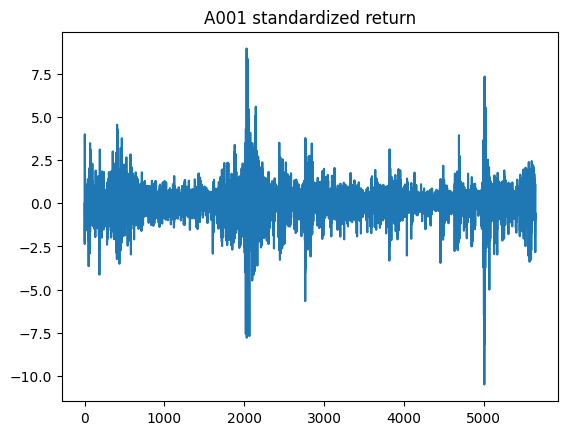

In [4]:
returns = data.load_returns(cfg)
counts = data.split_counts(returns)
train_series, test_series = data.split_series(returns)

print(f"returns      {counts['n_returns']:>6}  {counts['start_date']} to {counts['end_date']}")
print(f"train / test {counts['n_train']:>6} / {counts['n_test']}")
print(f"train end    {counts['train_end_date']}    test start {counts['test_start_date']}")

assert counts["n_returns"] == REFERENCE["n_returns"]
assert counts["n_train"] == REFERENCE["n_train"]
assert counts["n_test"] == REFERENCE["n_test"]
assert counts["start_date"] == REFERENCE["start_date"]
assert counts["train_end_date"] == REFERENCE["train_end_date"]
assert counts["test_start_date"] == REFERENCE["test_start_date"]

plots.plot_prices(returns["z_return"].to_numpy(dtype=float), title="A001 standardized return")


## Volatility regimes

Labels are loaded from the cache written by `scripts/01_label_regimes.py`. Clustering uses the **full** 2001–2022 A001 series. Labels are reordered so regime index increases with variance. Plots below show the full labeled series; the HMM is fit only on the train dates.


labels 5653 days  train 3395  test 2258


,n_days,mean,variance
regime,,,
0,3150,0.0260,0.3533
1,2063,-0.0125,0.9750
2,140,-0.0217,2.5675
3,175,-0.0701,3.5394
4,125,-0.3257,12.2582


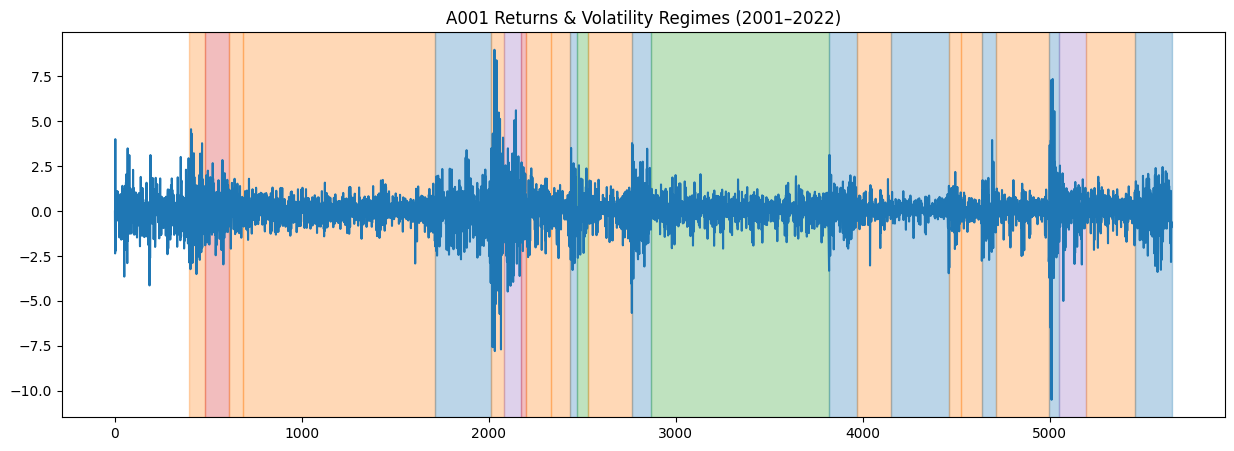

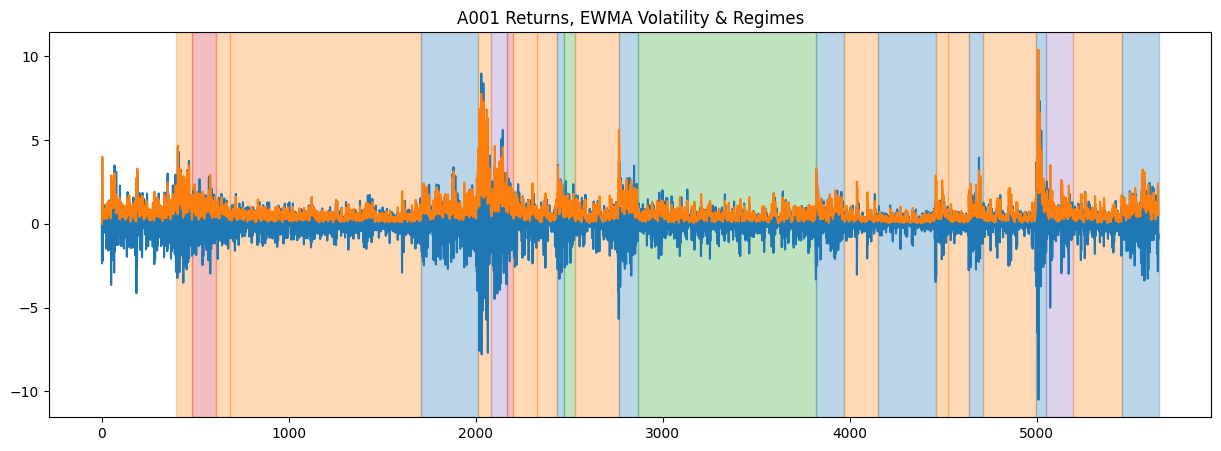

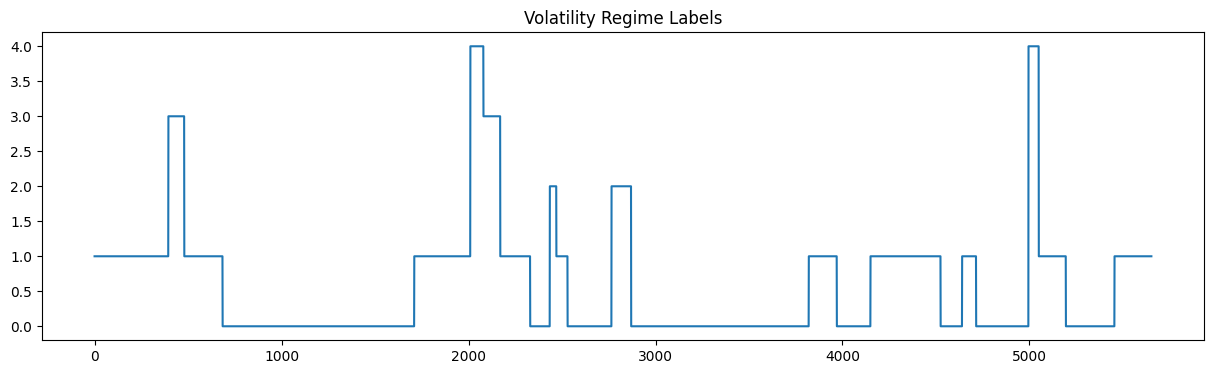

In [5]:
labels = regimes.load_labels(config_path(cfg, "regime_labels"))
regime_labels = labels.labels.astype(int)
train_labels, test_labels = data.split_labels(returns, regime_labels)
segment_colors = labels.segment_colors()

print(f"labels {len(regime_labels)} days  train {len(train_labels)}  test {len(test_labels)}")
display(plots.regime_moments(returns["z_return"].to_numpy(dtype=float), regime_labels, N_REGIMES))

plots.plot_regime_spans(
    returns["z_return"].to_numpy(dtype=float),
    labels.changepoints,
    segment_colors,
    title="A001 Returns & Volatility Regimes (2001–2022)",
)
plots.plot_regime_spans(
    returns["z_return"].to_numpy(dtype=float),
    labels.changepoints,
    segment_colors,
    overlay=regimes.ewm_volatility(returns["z_return"].to_numpy(dtype=float), cfg["regimes"]["ewm_com"]),
    title="A001 Returns, EWMA Volatility & Regimes",
)
plots.plot_regime_labels(regime_labels)


## Model frames and transition structure

`train_data` is 2001–2014 and `test_data` is 2014–2022. Each frame holds the A001 regime label, the A001 emission, and the lagged emission for the Markov switching variant. The empirical transition matrix below is estimated on the train labels, which is the path the HMM is trained against.


In [6]:
train_data, test_data = data.build_model_frames(returns, regime_labels, cfg)

coverage = pd.DataFrame(
    {
        "train": np.bincount(train_data.regime.values, minlength=N_REGIMES),
        "test": np.bincount(test_data.regime.values, minlength=N_REGIMES),
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(coverage)

missing_train = coverage.index[coverage["train"] == 0].tolist()
assert not missing_train, (
    f"Regimes {missing_train} are absent from the training slice, so their emission parameters "
    "would come from the prior. Re-run scripts/01_label_regimes.py with a different "
    "regimes.changepoint_penalty."
)
missing_test = coverage.index[coverage["test"] == 0].tolist()
if missing_test:
    print(
        f"Note: regimes {missing_test} do not occur in the test slice, so test accuracy "
        "is measured over the remaining regimes only."
    )


,train,test
regime,,
0,1890,1260
1,1120,943
2,140,0
3,175,0
4,70,55


Note: regimes [2, 3] do not occur in the test slice, so test accuracy is measured over the remaining regimes only.


In [7]:
empirical_transmat = regimes.empirical_transition_matrix(regime_labels, N_REGIMES)
outbound_transmat = regimes.outbound_transition_matrix(empirical_transmat, N_REGIMES)

index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")

print("Empirical transition matrix")
display(pd.DataFrame(empirical_transmat, index=index, columns=columns))

print("Outbound transition matrix (diagonal removed, rows renormalized)")
display(pd.DataFrame(outbound_transmat, index=index, columns=columns))

print("Average consecutive days per visit")
display(pd.Series(regimes.average_regime_length(regime_labels)).sort_index())

Empirical transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9975,0.0016,0.0006,0.0000,0.0003
1,0.0034,0.9956,0.0000,0.0005,0.0005
2,0.0071,0.0071,0.9857,0.0000,0.0000
3,0.0000,0.0114,0.0000,0.9886,0.0000
4,0.0000,0.0080,0.0000,0.0080,0.9840


Outbound transition matrix (diagonal removed, rows renormalized)


to,0,1,2,3,4
from,,,,,
0,0.0000,0.6250,0.2500,0.0000,0.1250
1,0.7778,0.0000,0.0000,0.1111,0.1111
2,0.5000,0.5000,0.0000,0.0000,0.0000
3,0.0000,1.0000,0.0000,0.0000,0.0000
4,0.0000,0.5000,0.0000,0.5000,0.0000


Average consecutive days per visit


0   393.7500
1   206.3000
2    70.0000
3    87.5000
4    62.5000
dtype: float64

## Diffusion pools

One pool of synthetic 128-day windows per regime, produced by that regime's specialist. Each pool is flattened into a sequence. Stitching walks a regime path and takes the next unused value from the matching pool. If specialists are not trained yet, placeholder pools resampled from real per-regime returns are used instead.


In [8]:
pools_root = config_path(cfg, "pools")
USING_PLACEHOLDER = not pools.pools_available(pools_root, N_REGIMES)
GENERATED_TITLE = (
    "PLACEHOLDER: Resampled Real Returns (not diffusion)"
    if USING_PLACEHOLDER
    else "HMM Diffusion Generated Returns"
)

if USING_PLACEHOLDER:
    print(
        "WARNING: no trained specialist pools found under "
        f"{pools_root.relative_to(REPO_ROOT)}.\n"
        "Falling back to placeholder pools resampled from the real per-regime returns.\n"
        "Run scripts/03_train_specialists.sh and scripts/04_generate_pools.py for real results."
    )
    generated_images = pools.placeholder_pools(
        train_series, train_labels, N_REGIMES, size=len(train_series), seed=0
    )
else:
    regime_stats = pools.regime_emission_stats(
        train_data.emission.values, train_data.regime.values, N_REGIMES
    )
    generated_images = pools.load_generated_images(
        pools_root,
        N_REGIMES,
        returns=returns,
        calibrate_regimes=regime_stats,
    )
    mu, sd = data.a001_log_return_scale(returns)
    print(f"Pool A001 rescaled: global z-score (mu={mu:.6e}, sd={sd:.6e}) + per-regime calibration")
    for k in range(N_REGIMES):
        meta = pools.load_pool_meta(pools_root, k)
        print(f"regime {k}: {meta.get('n_pool')} windows from {Path(meta.get('checkpoint_dir', '')).name}")

pool_summary = pd.DataFrame(
    {
        "pool_length": [generated_images[str(k)].size for k in range(N_REGIMES)],
        "pool_mean": [generated_images[str(k)].mean() for k in range(N_REGIMES)],
        "pool_var": [generated_images[str(k)].var() for k in range(N_REGIMES)],
        "real_mean": [train_series[train_labels == k].mean() for k in range(N_REGIMES)],
        "real_var": [train_series[train_labels == k].var() for k in range(N_REGIMES)],
    },
    index=pd.Index(range(N_REGIMES), name="regime"),
)
display(pool_summary)

# Every regime path that will be stitched below, so pool sufficiency is checked up front rather
# than failing partway through a variant.
candidate_paths = [train_data.regime.values, test_data.regime.values]
problems, _ = pools.check_pools(
    generated_images, candidate_paths, train_series, train_labels, N_REGIMES
)
for problem in problems:
    print(f"POOL CHECK: {problem}")
if not problems:
    print("Pool checks passed: finite, sufficient for every regime path, variance ordering matches.")


Pool A001 rescaled: global z-score (mu=2.683265e-04, sd=1.217831e-02) + per-regime calibration
regime 0: 128 windows from checkpoints\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_0
regime 1: 128 windows from checkpoints\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_1
regime 2: 128 windows from checkpoints\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_2
regime 3: 128 windows from checkpoints\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_3
regime 4: 128 windows from checkpoints\diffusion_denoised_x_UniTST_MP_ALL_RegimeWindows_1.0-KL2_N+1.0-Corr+1.0-FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE_specialist_regime_4


,pool_length,pool_mean,pool_var,real_mean,real_var
regime,,,,,
0,16384,0.0258,0.3530,0.0258,0.3530
1,16384,-0.0280,1.0839,-0.0280,1.0839
2,16384,-0.0217,2.5675,-0.0217,2.5675
3,16384,-0.0701,3.5394,-0.0701,3.5394
4,16384,-0.4163,12.8145,-0.4163,12.8145


Pool checks passed: finite, sufficient for every regime path, variance ordering matches.


## HMM variants

Four ways of estimating a transition matrix and per-regime Gaussian emission parameters. Supervised HMM treats regimes and emissions as observed and is fit with NUTS. Markov switching regresses the emission mean on the previous emission. Semi-supervised keeps labels on the first half of training and treats the second half as unlabeled. Neural HMM uses a small network for emission parameters fit by SVI.

All four are evaluated the same way: forward-backward smoothing, comparison to true labels, stitching along the estimated path, and per-regime moment tables. Top-2 accuracy is reported alongside top-1 because adjacent volatility regimes overlap heavily.


In [9]:
init_dist = models.initial_distribution(train_data, N_REGIMES)


def evaluate_variant(key, fit):
    """Fit diagnostics, state estimation, stitching, and plots for one HMM variant."""
    print("=" * 78)
    print(fit.name)
    print("=" * 78)

    print("Posterior transition matrix")
    display(pd.DataFrame(fit.transmat.round(3), index=index, columns=columns))
    print("Emission parameters")
    display(fit.summary())

    train_probs, train_est = models.estimate_states(
        fit, train_data.emission.values, init_dist, N_REGIMES
    )
    test_probs, test_est = models.estimate_states(
        fit, test_data.emission.values, init_dist, N_REGIMES
    )
    train_acc = models.accuracy_report(
        train_data.regime.values, train_est, train_probs, N_REGIMES, TOP_K
    )
    test_acc = models.accuracy_report(
        test_data.regime.values, test_est, test_probs, N_REGIMES, TOP_K
    )

    print(
        f"Train accuracy {train_acc['accuracy']:>7.2%}   "
        f"top-{TOP_K} {train_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
    )
    print(
        f"Test  accuracy {test_acc['accuracy']:>7.2%}   "
        f"top-{TOP_K} {test_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
    )

    plots.plot_estimates(train_est, train_data.regime.values, f"{fit.name}: Train")
    plots.plot_estimates(test_est, test_data.regime.values, f"{fit.name}: Test")

    oracle = stitch.stitch(generated_images, train_data.regime.values)
    estimated, test_estimated = plots.plot_paper_train_test(
        train_data.emission.values,
        train_data.regime.values,
        train_est,
        test_data.emission.values,
        test_data.regime.values,
        test_est,
        generated_images,
        generated_title=GENERATED_TITLE,
    )

    table = stitch.backtest_table(
        train_data.emission.values,
        train_data.regime.values,
        estimated,
        train_est,
        N_REGIMES,
    )
    test_table = stitch.backtest_table(
        test_data.emission.values,
        test_data.regime.values,
        test_estimated,
        test_est,
        N_REGIMES,
    )
    print("Train backtest")
    display(table)
    print("Test backtest")
    display(test_table)

    return {
        "name": fit.name,
        "fit": fit,
        "train_accuracy": train_acc["accuracy"],
        "train_top_k": train_acc[f"top_{TOP_K}_accuracy"],
        "test_accuracy": test_acc["accuracy"],
        "test_top_k": test_acc[f"top_{TOP_K}_accuracy"],
        "oracle": oracle,
        "estimated": estimated,
        "test_estimated": test_estimated,
        "backtest": table,
        "test_backtest": test_table,
    }


results = {}


sample: 100%|██████████| 300/300 [00:06<00:00, 46.86it/s, 15 steps of size 2.18e-01. acc. prob=0.82] 


Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0010,0.0010,0.0000,0.0000
1,0.0030,0.9950,0.0000,0.0010,0.0010
2,0.0080,0.0080,0.9810,0.0010,0.0010
3,0.0010,0.0120,0.0010,0.9850,0.0010
4,0.0040,0.0020,0.0030,0.0160,0.9750


Emission parameters


,mean,sigma
regime,,
0,0.0274,0.5952
1,-0.0279,1.0411
2,-0.0236,1.6168
3,-0.0749,1.8916
4,-0.3899,3.6466


100%|██████████| 3395/3395 [00:00<00:00, 100592.42it/s]
3395it [00:00, 97960.00it/s]
100%|██████████| 2258/2258 [00:00<00:00, 96599.77it/s]
2258it [00:00, 98439.21it/s]


Train accuracy  94.79%   top-2  98.65%
Test  accuracy  72.85%   top-2  94.38%


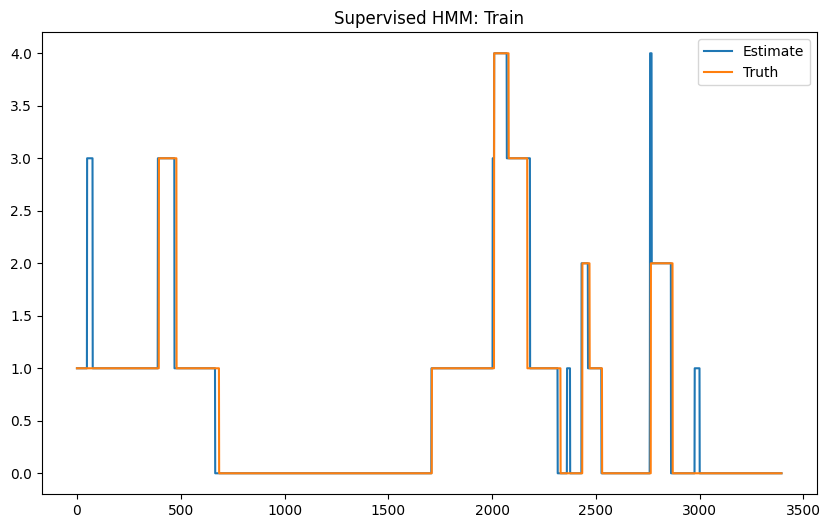

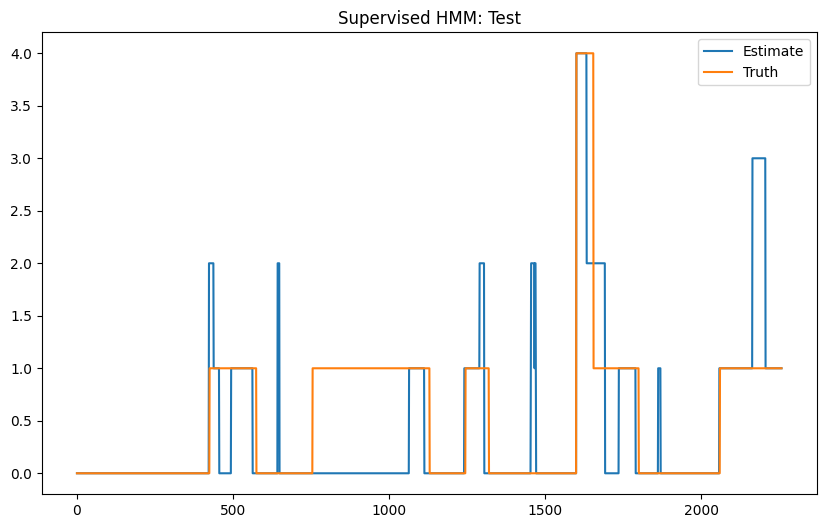

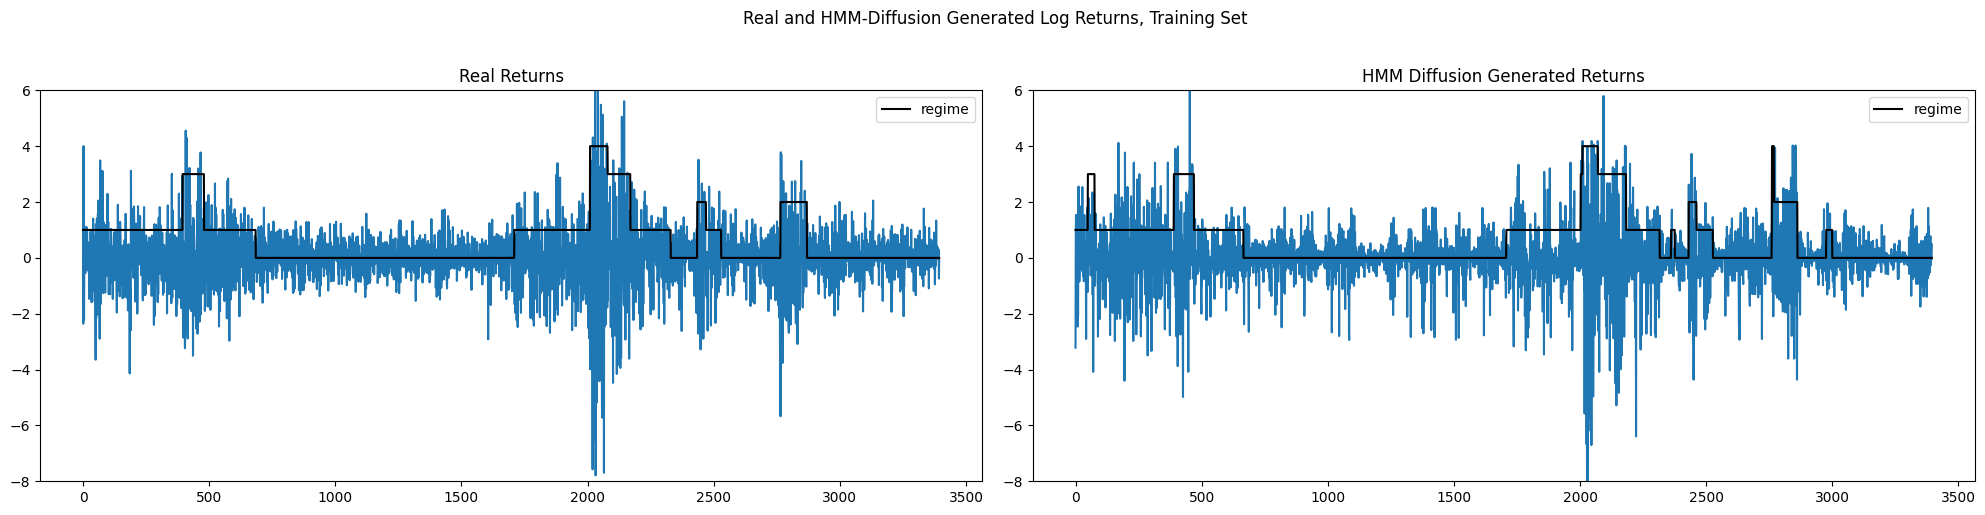

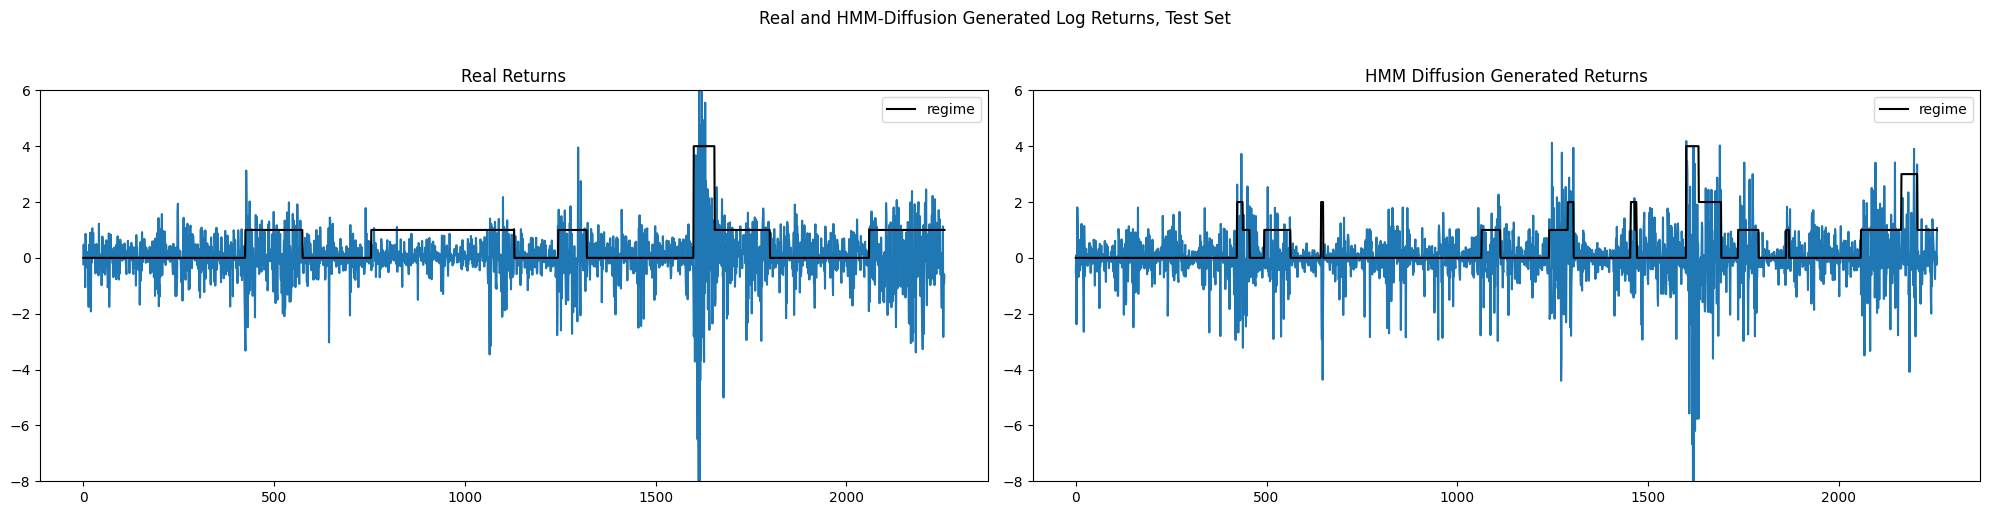

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1890,0.0258,0.0254,0.3532,0.3826
1,1120,-0.0280,0.0352,1.0849,1.2635
2,140,-0.0217,0.0197,2.5860,2.7759
3,175,-0.0701,0.0277,3.5598,3.9849
4,70,-0.4163,-0.6420,13.0002,12.4188


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1260,0.0262,0.0095,0.3539,0.4160
1,943,0.0060,0.0648,0.8460,1.1461
2,0,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN
4,55,-0.2102,-0.8888,11.7398,11.1370


In [10]:
results["supervised"] = evaluate_variant(
    "supervised", models.fit_supervised_hmm(train_data, N_REGIMES, cfg)
)

sample: 100%|██████████| 300/300 [00:07<00:00, 42.34it/s, 15 steps of size 1.93e-01. acc. prob=0.88] 

Markov Switching Model
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9970,0.0010,0.0010,0.0000,0.0000
1,0.0030,0.9950,0.0000,0.0010,0.0010
2,0.0080,0.0080,0.9800,0.0020,0.0020
3,0.0010,0.0130,0.0010,0.9840,0.0010
4,0.0020,0.0030,0.0040,0.0180,0.9730


Emission parameters


,mean,sigma
regime,,
0,0.0290,0.5935
1,-0.0312,1.0374
2,-0.0200,1.6129
3,-0.0729,1.8910
4,-0.4019,3.5613


100%|██████████| 3395/3395 [00:00<00:00, 92180.42it/s]
3395it [00:00, 91735.03it/s]
100%|██████████| 2258/2258 [00:00<00:00, 90114.26it/s]
2258it [00:00, 92681.37it/s]


Train accuracy  94.26%   top-2  98.59%
Test  accuracy  72.67%   top-2  95.13%


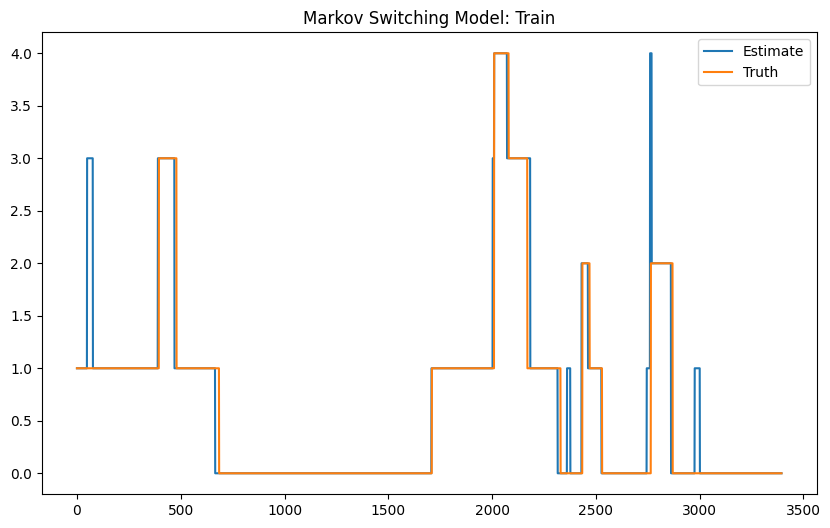

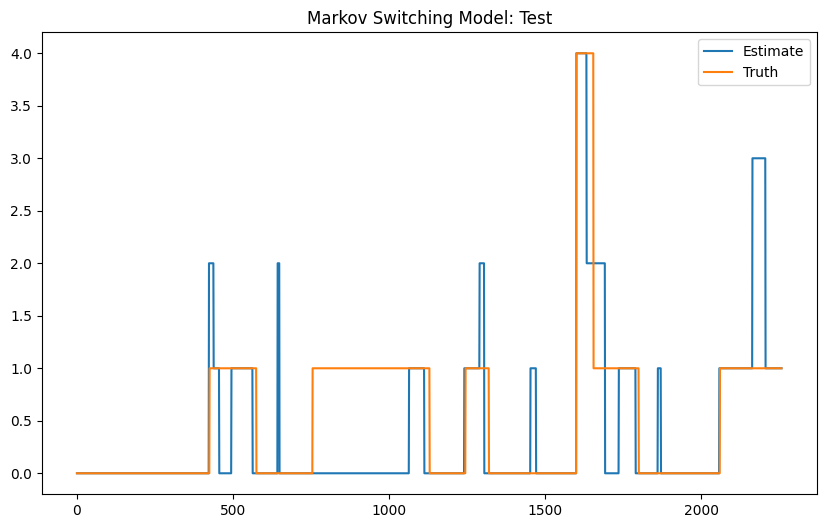

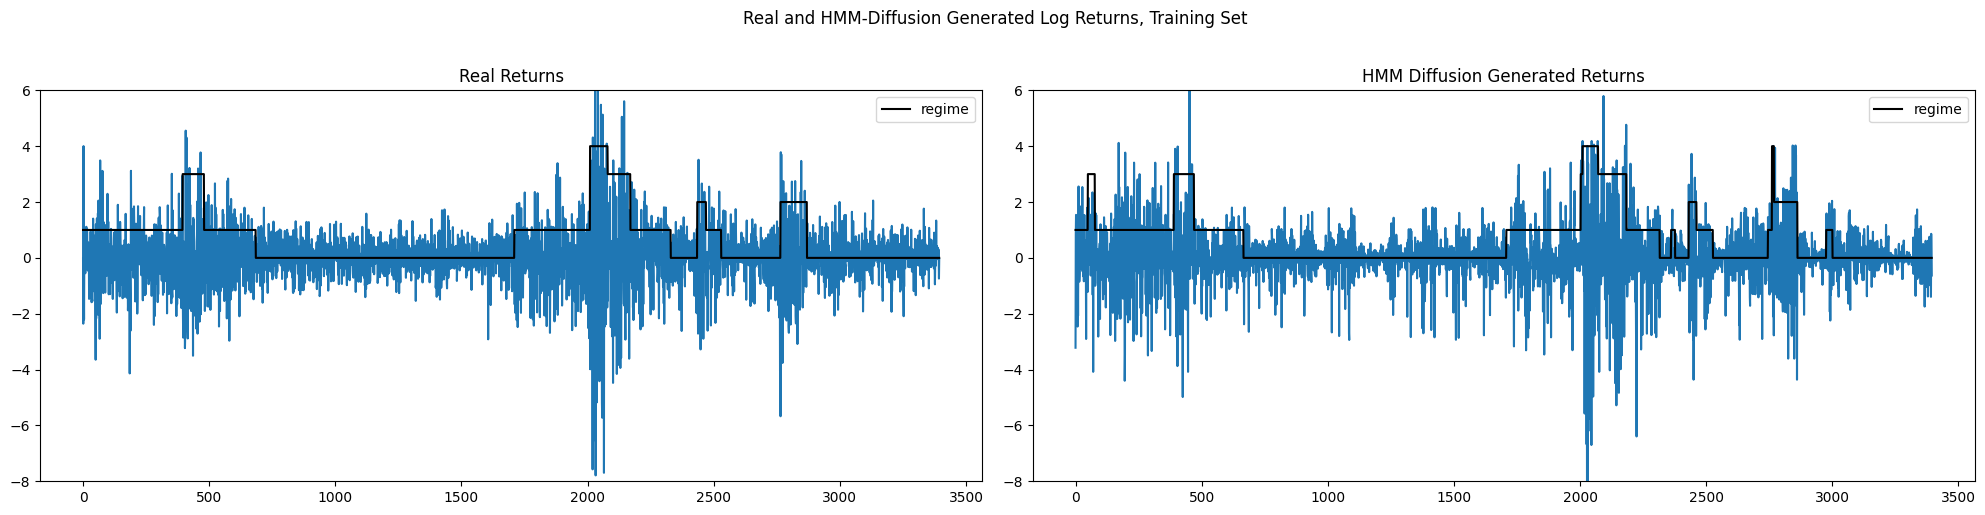

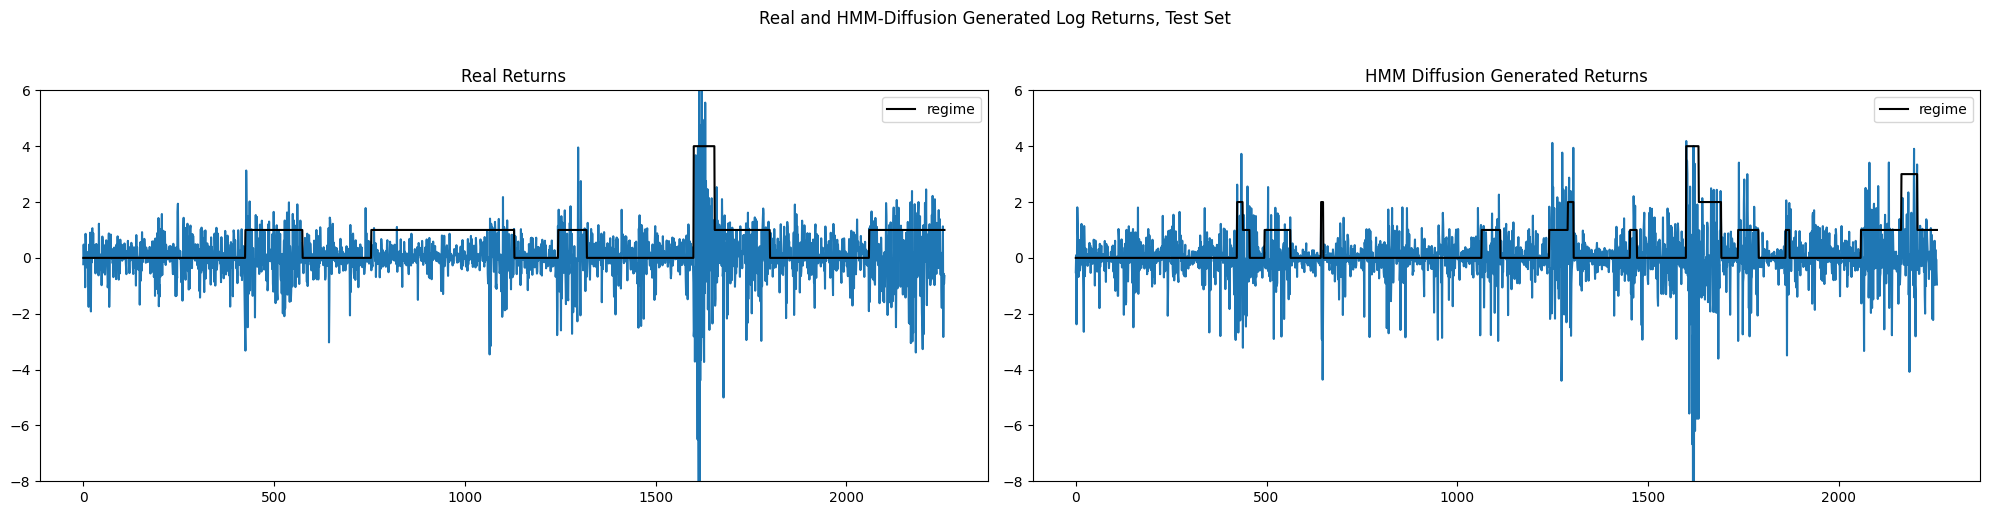

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1890,0.0258,0.0240,0.3532,0.3965
1,1120,-0.0280,0.0412,1.0849,1.2957
2,140,-0.0217,-0.0207,2.5860,2.7390
3,175,-0.0701,0.0307,3.5598,3.9842
4,70,-0.4163,-0.6627,13.0002,12.2531


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1260,0.0262,0.0112,0.3539,0.4381
1,943,0.0060,0.0510,0.8460,1.0814
2,0,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN
4,55,-0.2102,-0.9164,11.7398,10.9178


In [11]:
results["markov_switching"] = evaluate_variant(
    "markov_switching", models.fit_markov_switching(train_data, N_REGIMES, cfg)
)

[ -0.06482968 -28.640368   -50.493526    -1.6066898   -2.6695418 ]
(1697,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891284]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2733107]
 [-0.4881314 -1.81827   -2.438177  -2.2725506 -3.394642 ]
 [-2.8772955 -2.5834103 -2.6981206 -0.8134196 -1.0285479]]
loc
[-0.27706242 -1.3087606   1.4700975  -1.1474452   0.5143523 ]
(5,)
[0.28611243 0.16749428 0.1470359  0.8830496  5.7329273 ]
(5,)
(5, 5)
[ -0.06482968 -28.640368   -50.493526    -1.6066898   -2.6695418 ]
log_prob
GradTracer(primal=[ -0.06482968 -28.640368   -50.493526    -1.6066898   -2.6695418 ], typeof(tangent)=f32[5])
(1697,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=[[-2.603052  -1.7607605 -2.4121323 -2.3816977 -0.5585793]
 [-1.3753742 -0.9098027 -2.8357787 -1.4681387 -2.8891287]
 [-1.9357654 -0.687541  -3.4661908 -3.1763897 -1.2

  0%|          | 0/300 [00:00<?, ?it/s]

GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(1697,)
prev
JitTracer(float32[5])
cur
JitTracer(float32[])
trans
GradTracer(primal=JitTracer(float32[5,5]), typeof(tangent)=f32[5,5])
loc
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
(5,)
(5, 5)
GradTracer(primal=JitTracer(float32[5]), typeof(tangent)=f32[5])
log_prob


sample: 100%|██████████| 300/300 [00:04<00:00, 62.65it/s, 11 steps of size 4.28e-02. acc. prob=0.69]

Semi-Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.7930,0.1230,0.0560,0.0240,0.0040
1,0.1440,0.4700,0.2210,0.1020,0.0630
2,0.3800,0.0350,0.0660,0.1530,0.3660
3,0.4370,0.0430,0.3250,0.0460,0.1490
4,0.2010,0.2270,0.1370,0.1010,0.3350


Emission parameters


,mean,sigma
regime,,
0,0.0321,0.6797
1,-0.0169,0.9584
2,1.8067,4.1233
3,-0.4091,1.4570
4,0.7746,1.3637


100%|██████████| 3395/3395 [00:00<00:00, 53466.43it/s]
3395it [00:00, 86213.72it/s]
100%|██████████| 2258/2258 [00:00<00:00, 94909.54it/s]
2258it [00:00, 96082.32it/s]


Train accuracy  59.71%   top-2  88.45%
Test  accuracy  57.88%   top-2  95.31%


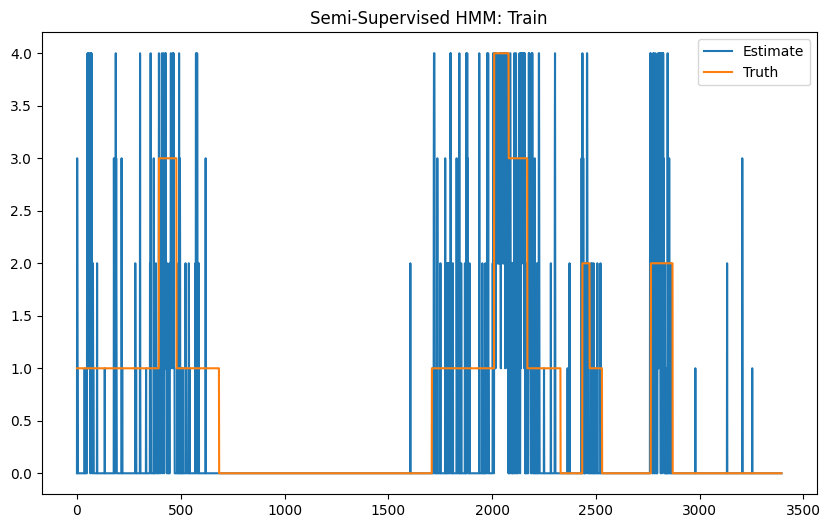

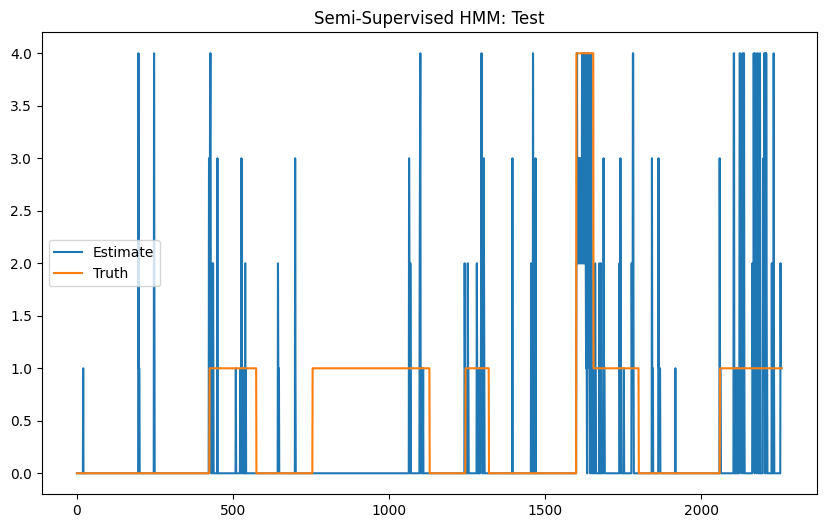

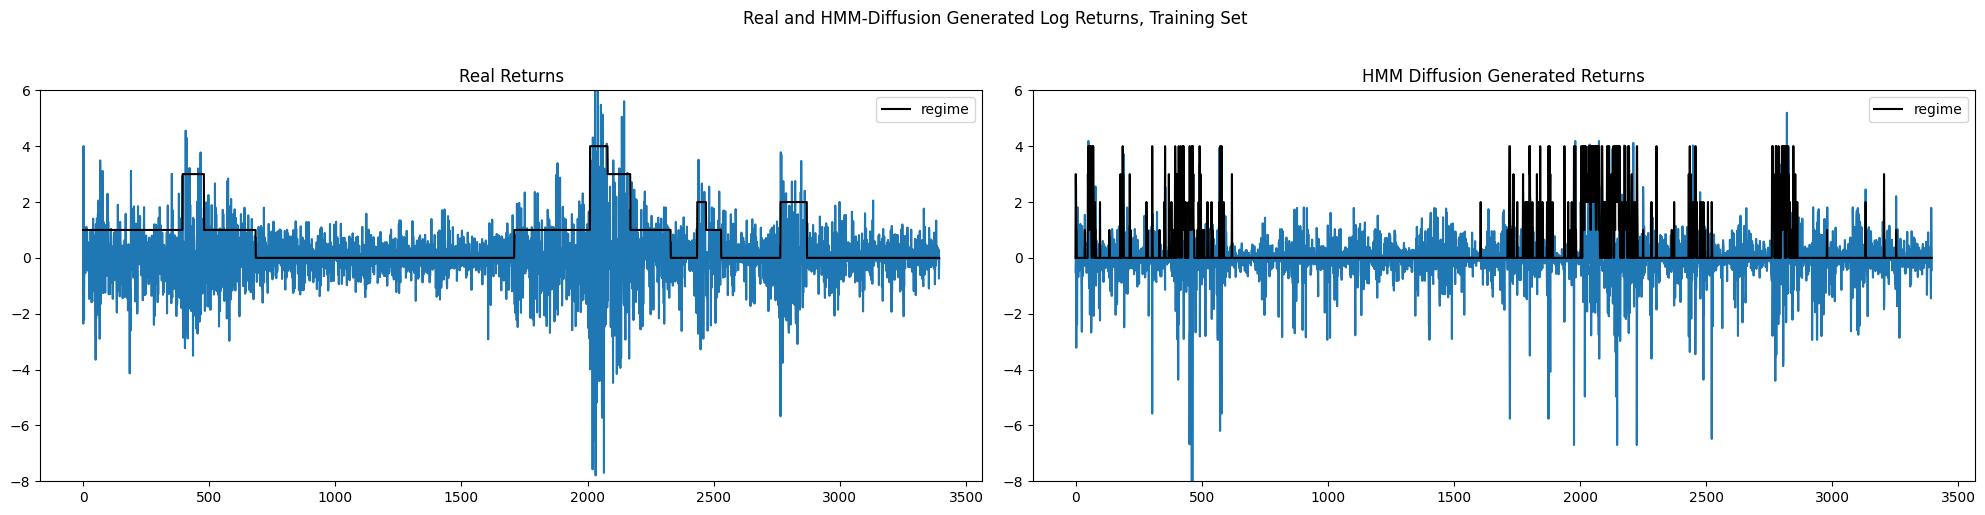

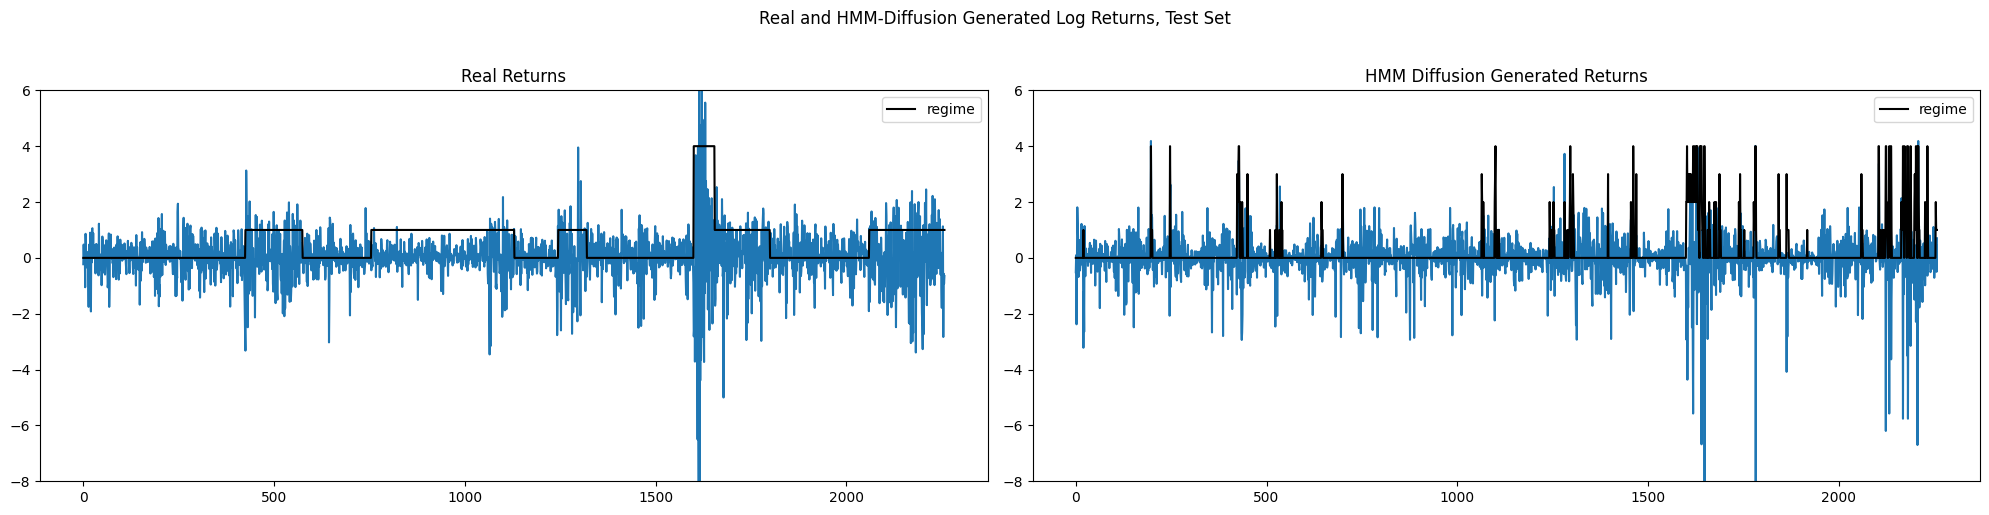

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1890,0.0258,0.0254,0.3532,0.4205
1,1120,-0.0280,-0.0240,1.0849,0.9546
2,140,-0.0217,0.0283,2.5860,2.6051
3,175,-0.0701,-0.2507,3.5598,4.1089
4,70,-0.4163,0.1329,13.0002,3.3097


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1260,0.0262,0.0223,0.3539,0.4084
1,943,0.0060,0.0066,0.8460,0.9208
2,0,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN
4,55,-0.2102,-0.6186,11.7398,6.3176


In [12]:
results["semi_supervised"] = evaluate_variant(
    "semi_supervised", models.fit_semi_supervised_hmm(train_data, N_REGIMES, cfg)
)

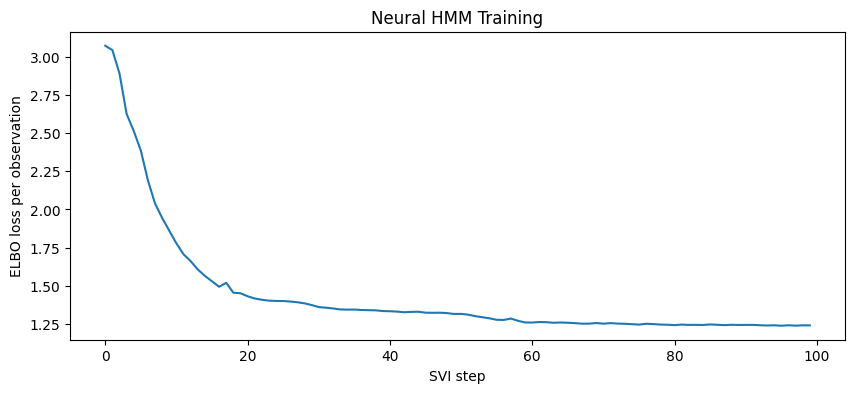

Neural HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.9900,0.0030,0.0030,0.0020,0.0020
1,0.0030,0.9900,0.0020,0.0020,0.0020
2,0.0020,0.0020,0.9930,0.0010,0.0010
3,0.0010,0.0040,0.0010,0.9920,0.0010
4,0.0000,0.0000,0.0000,0.0020,0.9970


Emission parameters


,mean,sigma
regime,,
0,0.0235,0.6012
1,-0.0239,1.0174
2,-0.0742,1.5209
3,-0.1084,1.8786
4,-0.2747,3.7723


100%|██████████| 3395/3395 [00:00<00:00, 96801.28it/s]
3395it [00:00, 99511.25it/s]
100%|██████████| 2258/2258 [00:00<00:00, 100079.66it/s]
2258it [00:00, 100435.20it/s]

Train accuracy  93.52%   top-2  98.11%
Test  accuracy  72.01%   top-2  94.29%


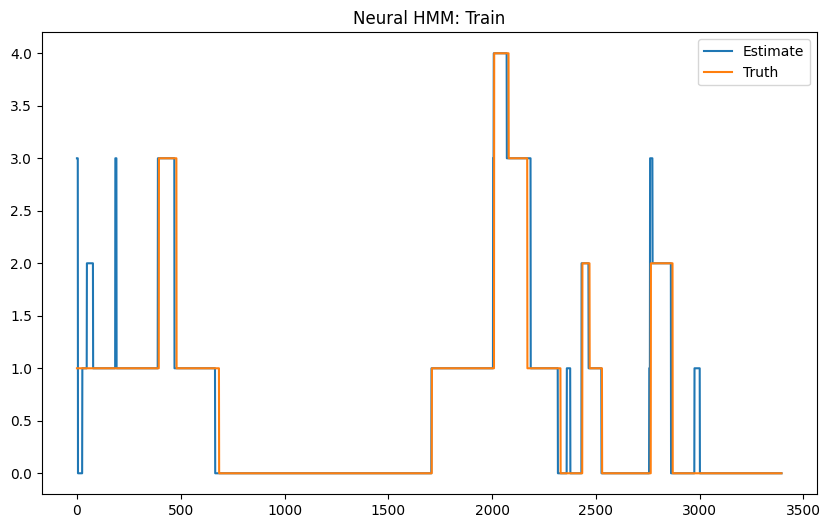

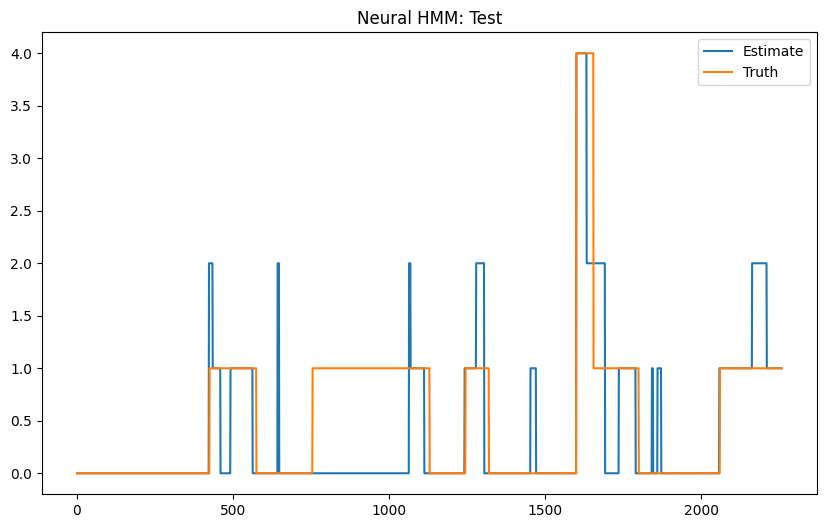

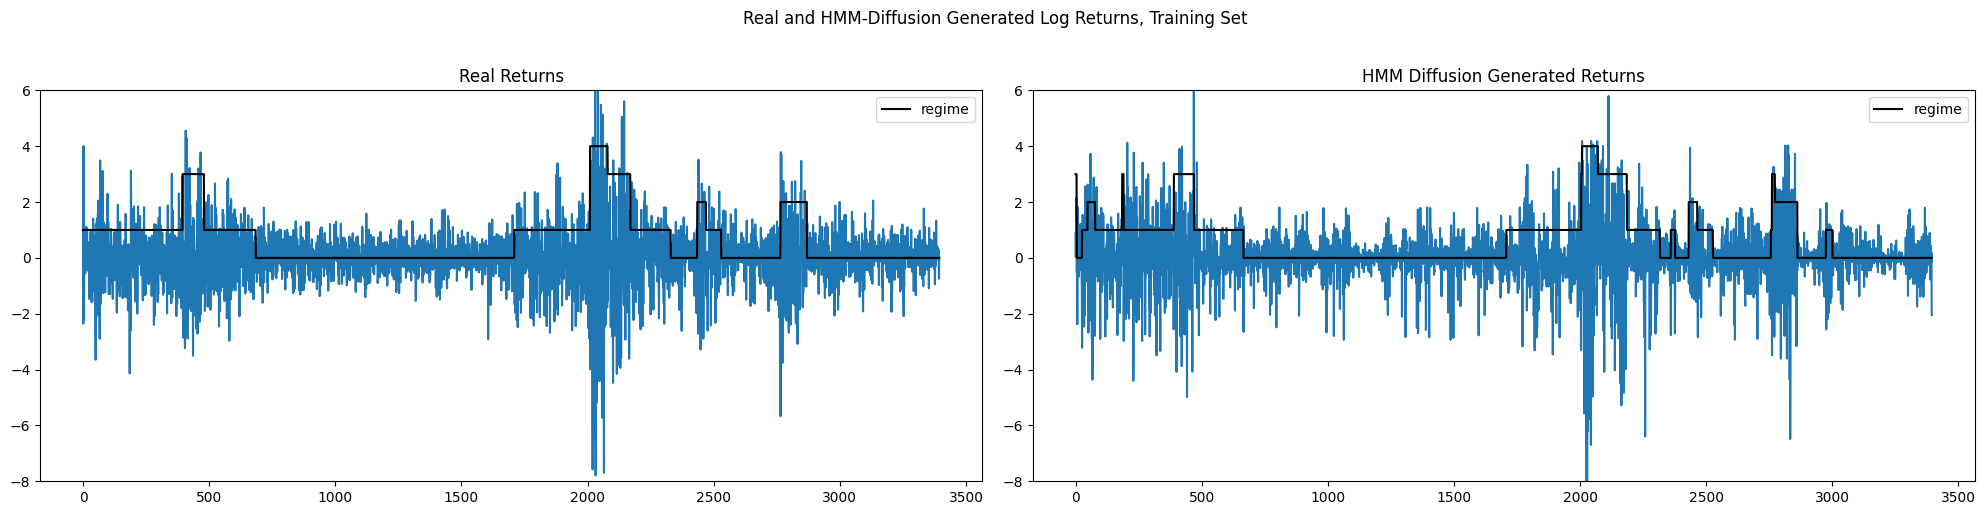

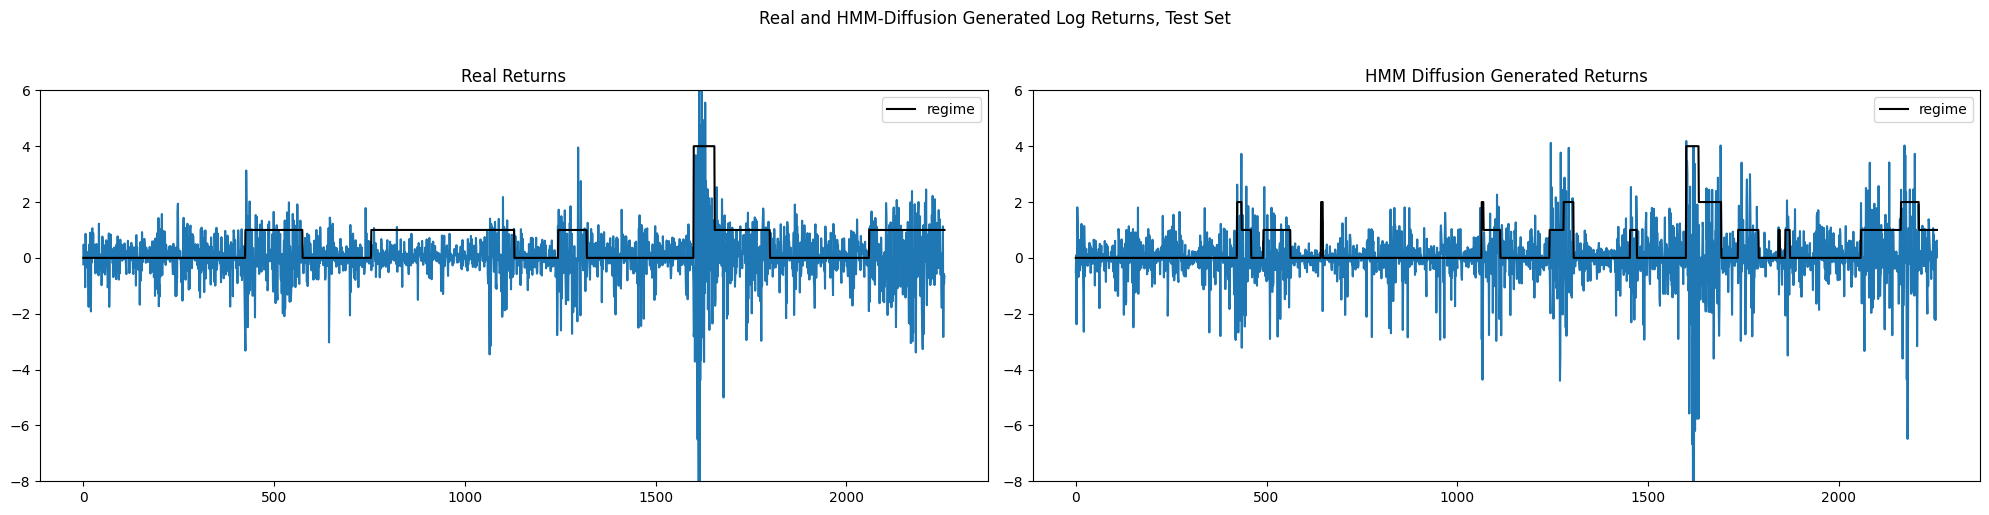

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1890,0.0258,0.0133,0.3532,0.4035
1,1120,-0.0280,-0.0020,1.0849,1.2610
2,140,-0.0217,0.0707,2.5860,2.9496
3,175,-0.0701,0.1133,3.5598,3.8267
4,70,-0.4163,-0.3879,13.0002,12.4325


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1260,0.0262,0.0217,0.3539,0.4220
1,943,0.0060,0.0260,0.8460,1.2554
2,0,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN
4,55,-0.2102,-0.9145,11.7398,11.0113


In [13]:
neural_fit = models.fit_neural_hmm(train_data, N_REGIMES, cfg)
plots.plot_elbo(neural_fit.diagnostics["elbo_losses"])
results["neural"] = evaluate_variant("neural", neural_fit)

## Results

State-estimation accuracy for all four variants, then the per-regime distributional fit of the generated series. The moment comparison is grouped by the true regime while generated values follow the estimated path. The oracle column stitches along the true path to isolate generator quality.


In [14]:
summary = pd.DataFrame(
    [
        {
            "variant": r["name"],
            "train": r["train_accuracy"],
            f"train_top{TOP_K}": r["train_top_k"],
            "test": r["test_accuracy"],
            f"test_top{TOP_K}": r["test_top_k"],
        }
        for key, r in results.items()
    ]
).set_index("variant")

display(summary.style.format("{:.2%}"))


,train,train_top2,test,test_top2
variant,,,,
Supervised HMM,94.79%,98.65%,72.85%,94.38%
Markov Switching Model,94.26%,98.59%,72.67%,95.13%
Semi-Supervised HMM,59.71%,88.45%,57.88%,95.31%
Neural HMM,93.52%,98.11%,72.01%,94.29%


In [15]:
best_key = summary["test"].idxmax()
best = next(r for r in results.values() if r["name"] == best_key)

oracle_table = stitch.backtest_table(
    train_data.emission.values,
    train_data.regime.values,
    best["oracle"],
    train_data.regime.values,
    N_REGIMES,
)

comparison = pd.DataFrame(
    {
        "real_var": oracle_table["real_var"],
        "oracle_var": oracle_table["gen_var"],
        "hmm_var": best["backtest"]["gen_var"],
        "real_mean": oracle_table["real_mean"],
        "oracle_mean": oracle_table["gen_mean"],
        "hmm_mean": best["backtest"]["gen_mean"],
    }
)

print(f"Per-regime moments, stitched with {best_key}")
display(comparison)

if USING_PLACEHOLDER:
    print(
        "\nThese generated columns come from placeholder resampling, not the diffusion specialists."
    )


Per-regime moments, stitched with Supervised HMM


,real_var,oracle_var,hmm_var,real_mean,oracle_mean,hmm_mean
regime,,,,,,
0,0.3532,0.3713,0.3826,0.0258,0.0247,0.0254
1,1.0849,1.1736,1.2635,-0.0280,-0.0056,0.0352
2,2.5860,3.1451,2.7759,-0.0217,-0.0356,0.0197
3,3.5598,3.4374,3.9849,-0.0701,0.2877,0.0277
4,13.0002,12.5009,12.4188,-0.4163,-0.5353,-0.6420
